[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [14]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [15]:
df = pd.read_csv("mushrooms.csv")


---
## 3. Etapa 2 — Exploración y preparación de datos

In [16]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
print(df.describe(include='all'))

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  

In [17]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

print(f'Registros duplicados: {df.duplicated().sum()}')

Valores nulos por columna:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Registros duplicados: 0
Registros duplicados: 0


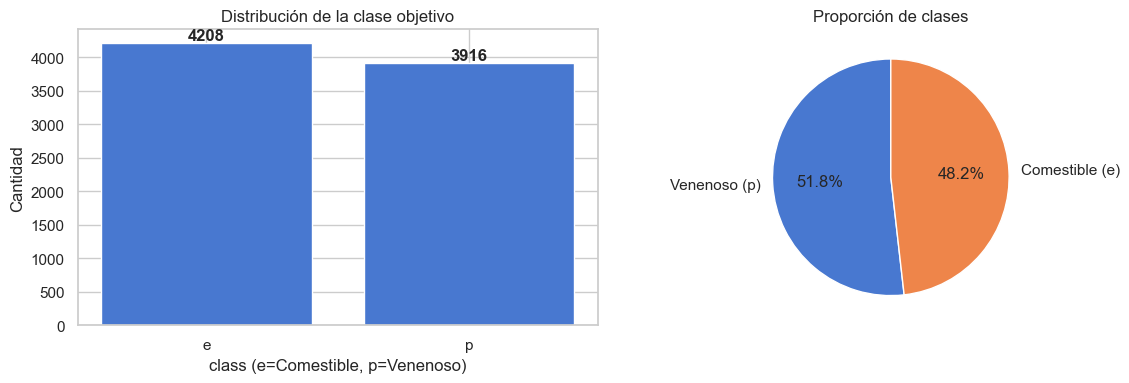

In [18]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['class'].value_counts()

axes[0].bar(
    target_counts.index.astype(str),
    target_counts.values
)

axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('class (e=Comestible, p=Venenoso)')
axes[0].set_ylabel('Cantidad')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(
    target_counts.values,
    labels=['Venenoso (p)', 'Comestible (e)'],
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

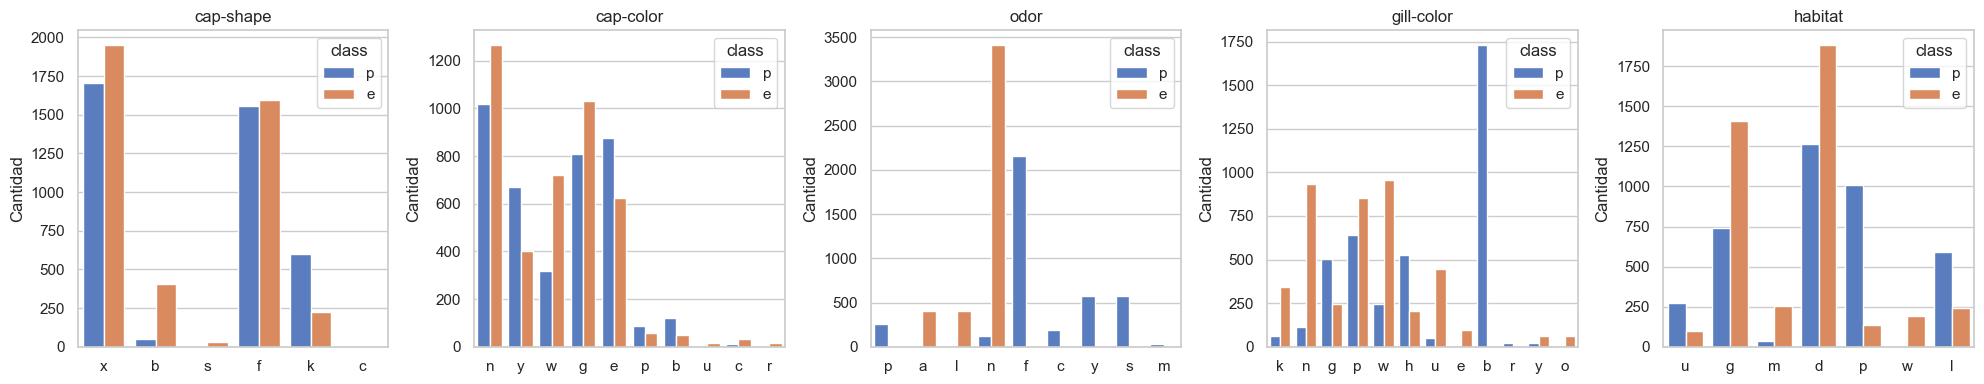

In [19]:
# 3.4  Distribución de variables numéricas clave
cat_cols = ['cap-shape', 'cap-color', 'odor', 'gill-color', 'habitat']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='class',
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

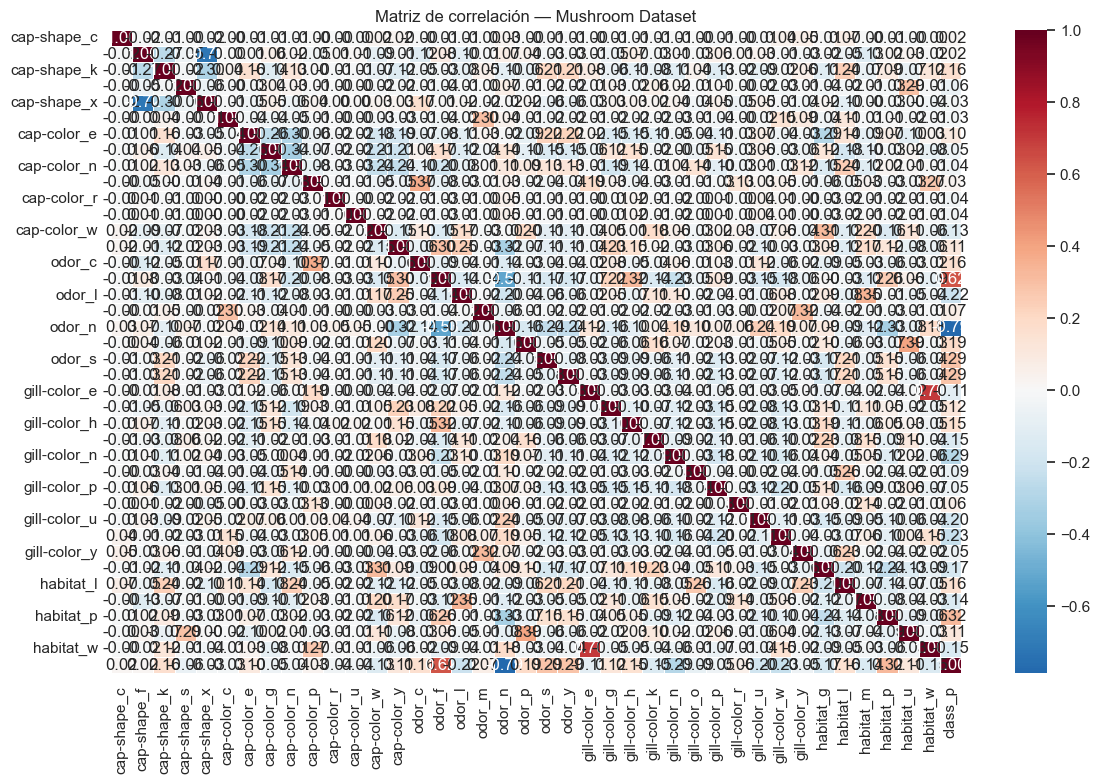

In [20]:
selected_cols = ['cap-shape', 'cap-color', 'odor', 'gill-color', 'habitat', 'class']

encoded = pd.get_dummies(df[selected_cols], drop_first=True)

corr = encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de correlación — Mushroom Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [21]:
# 4.1  Separación de features y target
X = df.drop(columns='class')
y = df['class']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (8124, 22)
Target:   (8124,)


In [22]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
categorical_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 6499 muestras
Test:  1625 muestras

Proporción target en train:
class
e    0.518
p    0.482
Name: proportion, dtype: float64

Proporción target en test:
class
e    0.518
p    0.482
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [23]:
# 5.1 Definición de pipelines

pipelines = {
    'LogisticRegression': Pipeline([
        ('encoder', preprocessor),
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    'DecisionTree': Pipeline([
        ('encoder', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),

    'RandomForest': Pipeline([
        ('encoder', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            random_state=42
        ))
    ])
}
# 5.2 Entrenamiento y validación cruzada (5-fold)

results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    results[name] = scores

    print(
        f'{name:25s} '
        f'Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}'
    )

LogisticRegression        Accuracy CV: 0.9997 ± 0.0006
DecisionTree              Accuracy CV: 0.9997 ± 0.0006
RandomForest              Accuracy CV: 0.9994 ± 0.0012


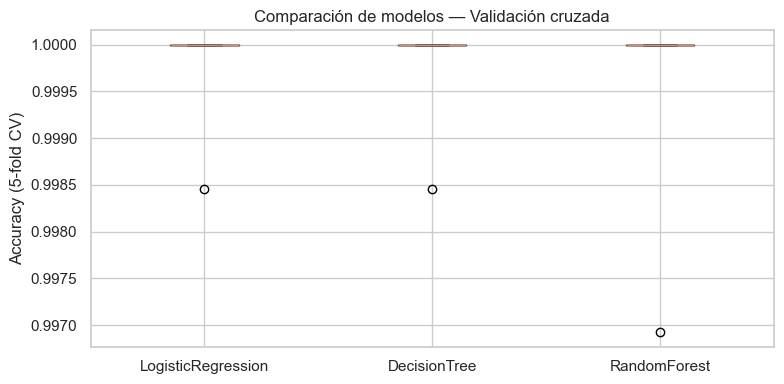

In [24]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [25]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Comestible', 'Venenoso']))

Mejor modelo: LogisticRegression
Accuracy en test: 1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Comestible       1.00      1.00      1.00       842
    Venenoso       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



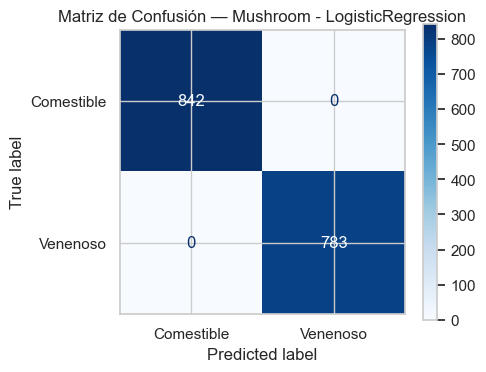

In [26]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Comestible', 'Venenoso'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — Mushroom - {best_name}')
plt.tight_layout()
plt.show()

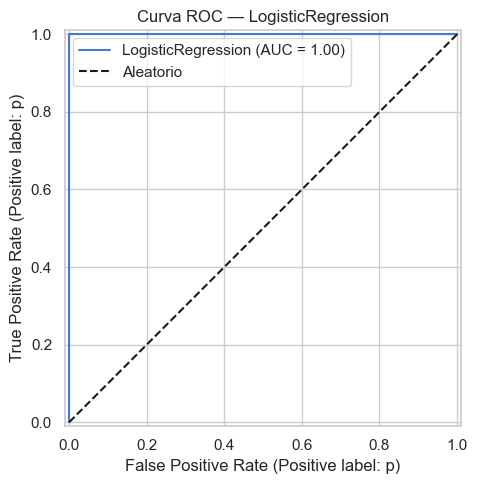

In [27]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [28]:
# 7.1  Guardar el modelo
MODEL_PATH = 'mushroom_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: mushroom_model.joblib


In [29]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [30]:
# 7.3  Función de inferencia (simula un endpoint de predicción)
# 7.3 PREDICCIÓN DE UN EJEMPLO DE MUSHROOM

ejemplo = X_test.iloc[[0]]

prediccion = loaded_model.predict(ejemplo)[0]

if prediccion == 'e':
    print("Predicción: COMESTIBLE")
else:
    print("Predicción: VENENOSO")

ejemplo = X_test.iloc[[0]]

prediccion = loaded_model.predict(ejemplo)[0]
probabilidades = loaded_model.predict_proba(ejemplo)[0]

print("\n" + "=" * 60)
print("PREDICCIÓN DE UN EJEMPLO")
print("=" * 60)

print("Predicción:", "COMESTIBLE" if prediccion == 'e' else "VENENOSO")

for clase, prob in zip(loaded_model.classes_, probabilidades):
    nombre = "COMESTIBLE" if clase == 'e' else "VENENOSO"
    print(f"Probabilidad {nombre}: {prob:.2%}")

Predicción: VENENOSO

PREDICCIÓN DE UN EJEMPLO
Predicción: VENENOSO
Probabilidad COMESTIBLE: 0.04%
Probabilidad VENENOSO: 99.96%


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*